In [ ]:
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')
from src import plot_utils as pu

import seaborn as sns


[]
No fonts found


In [2]:
# --- Load CSVs ---
root = Path('.')
curve_csv = next(root.glob('wandb_export_*_48.*.csv'), None)
summary_csv = next(root.glob('wandb_export_*_57.*.csv'), None)

if curve_csv is None or summary_csv is None:
    # Fallback: pick by structure if filenames differ
    csvs = list(root.glob('wandb_export_*.csv'))
    for p in csvs:
        with p.open(newline='') as f:
            header = next(csv.reader(f))
        if 'Step' in header:
            curve_csv = p
        if header[:3] == ['Name', '_wandb', 'test_top_1']:
            summary_csv = p

print('curve_csv:', curve_csv)
print('summary_csv:', summary_csv)

# Read summary metrics
run_to_test = {}
if summary_csv:
    with summary_csv.open(newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            name = row.get('Name', '').strip()
            val = row.get('test_top_1', '').strip()
            if name and val:
                try:
                    run_to_test[name] = float(val)
                except ValueError:
                    pass

# Read curves
steps = []
series = {}  # run_name -> dict(value, min, max)
if curve_csv:
    with curve_csv.open(newline='') as f:
        reader = csv.DictReader(f)
        # parse column mapping
        cols = reader.fieldnames or []
        # Identify run base names for train_loss columns
        for col in cols:
            if col.endswith(' - train_loss'):
                run = col[:-len(' - train_loss')]
                series[run] = {
                    'value': col,
                    'min': col + '__MIN',
                    'max': col + '__MAX',
                }

        for row in reader:
            if 'Step' in row:
                try:
                    steps.append(float(row['Step']))
                except ValueError:
                    steps.append(np.nan)

            # Build per-run lists
            for run, keys in series.items():
                keys.setdefault('values', [])
                keys.setdefault('mins', [])
                keys.setdefault('maxs', [])
                v = row.get(keys['value'], '')
                vmin = row.get(keys['min'], '')
                vmax = row.get(keys['max'], '')
                def parse(x):
                    try:
                        return float(x)
                    except ValueError:
                        return np.nan
                keys['values'].append(parse(v))
                keys['mins'].append(parse(vmin))
                keys['maxs'].append(parse(vmax))

# Convert steps to numpy
steps = np.array(steps, dtype=float)


curve_csv: wandb_export_2025-12-18T23_17_48.704-05_00.csv
summary_csv: wandb_export_2025-12-18T23_17_57.709-05_00.csv


In [3]:
eg_c = "#f05039" 
gd_c = "#1f449c" 

r50_imagenet_sgd_0.5_5e-5_0_lognormal_0_0_cosine_no_bn_default_False_labels_FINAL (test_top_1=0.7817)
r50_imagenet_sgd_eg_split_bias_0.4_5e-5_0_lognormal_0_0_cosine_no_bn_default_False_labels_FINAL (test_top_1=0.7313)


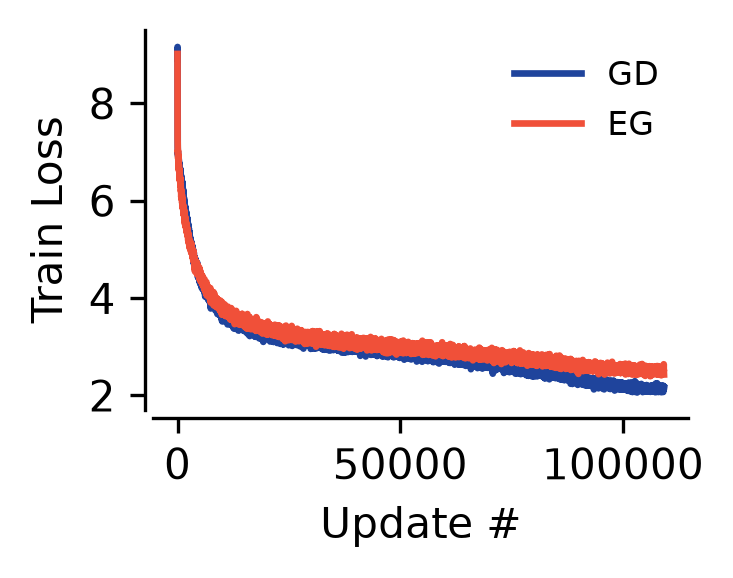

In [ ]:
# --- Plot learning curves ---
# Filter runs by substring 
name_filter = 'lognormal'  

# Plot settings
plt.figure(figsize=(2.5,2.), dpi = 300)

runs = sorted(series.keys())
if name_filter:
    runs = [r for r in runs if name_filter in r]

for run in runs:
    data = series[run]
    y = np.array(data['values'], dtype=float)
    y_min = np.array(data['mins'], dtype=float)
    y_max = np.array(data['maxs'], dtype=float)

    label = run
    if run in run_to_test:
        label = f"{run} (test_top_1={run_to_test[run]:.4f})"
    
    print(label)
    if "_eg_" in label:
        label = "EG"
        c = eg_c
    else:
        label = "GD"
        c = gd_c

    plt.plot(steps, y, linewidth=1.6, label=label, c=c)
    # Only shade if min/max look valid
    if np.isfinite(y_min).any() and np.isfinite(y_max).any():
        plt.fill_between(steps, y_min, y_max, alpha=0.12)


plt.xlabel('Update #')
plt.ylabel('Train Loss')
#plt.title('Learning Curves')
#plt.grid(True, alpha=0.2)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
sns.despine(offset=2, trim=False)
plt.savefig("imagenet_train_loss.pdf", bbox_inches='tight', pad_inches=0 )


['r50_imagenet_sgd_0.5_5e-5_0_lognormal_0_0_cosine_no_bn_default_False_labels_FINAL', 'r50_imagenet_sgd_eg_split_bias_0.4_5e-5_0_lognormal_0_0_cosine_no_bn_default_False_labels_FINAL']


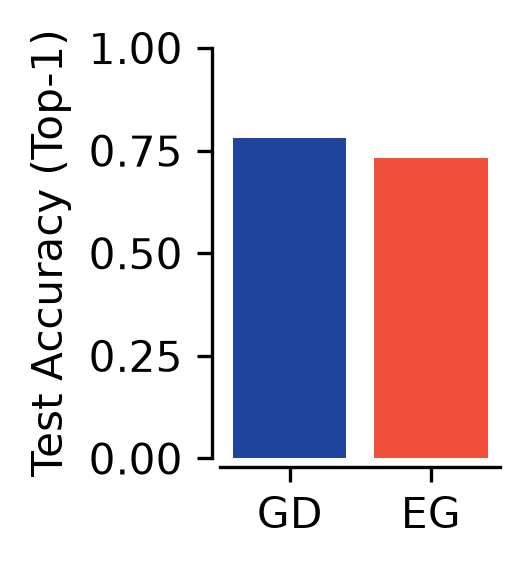

In [5]:
# --- Bar chart of final accuracy (test_top_1) ---
# Uses same name_filter as above


runs = sorted(run_to_test.keys())
if name_filter:
    runs = [r for r in runs if name_filter in r]
print(runs)

vals = [run_to_test[r] for r in runs]

labels, colours = [], []
for label in runs:
    if "_eg_" in label:
        
        label = "EG"
        c = eg_c
    else:
        label = "GD"
        c = gd_c
    labels.append(label)
    colours.append(c)

plt.figure(figsize=(1.75,2.), dpi = 300)
plt.bar(range(len(runs)), vals, color=colours)
plt.ylabel('Test Accuracy (Top-1)')
#plt.title('Final Accuracy by Run')
# Show abbreviated names to keep readable
#xt = [r if len(r) <= 25 else r[:22] + '...' for r in runs]
plt.xticks(range(len(runs)), labels, rotation=30, ha='right', fontsize=8)
plt.ylim(0, 1.0)
plt.tight_layout()

sns.despine(offset=2)
plt.savefig("imagenet_test_acc.pdf")

